**Linear regressor**

Fabio Scotti fabio.scotti@unimi.it

Course: Intelligent systems for industry, supply chain and environment

A COLAB demo for  
 - creating and training the regressor
 - assessment of the accuracy 

## Import the needed libraries

In [0]:
import matplotlib.pyplot as plt
import numpy as np

## 1D Linear Regression

We want to create a model wich is a a straight-line fit of the form
$$
y = ax + b
$$

Consider the following data, which is scattered about a line with a slope of 2 and an intercept of -5:

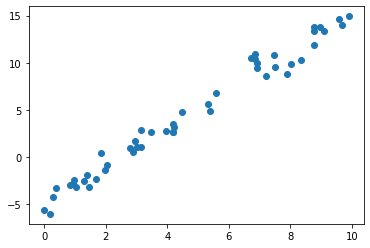

In [2]:
rng = np.random.RandomState(1)
num_points = 50
x = 10 * rng.rand(num_points )
t = 2 * x - 5 + rng.randn(num_points )
plt.scatter(x, t);

We can use Scikit-Learn's ``LinearRegression`` estimator to fit this data and construct the best-fit line:

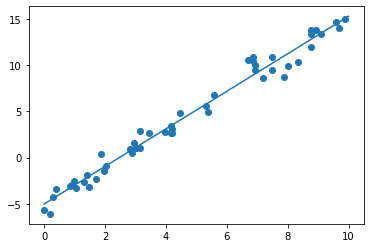

In [3]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)

model.fit(x[:, np.newaxis], t) # newaxis adds a dimension (needed from the function)

y1 = model.predict(x[:, np.newaxis])  # let's create the predicted values

xfit = np.linspace(0, 10, 1000)  # let's create an array to test the regressor [0 ... 10] of 1000 points
y1_test = model.predict(xfit[:, np.newaxis])  # let's create the predicted values

plt.scatter(x, t)
plt.plot(xfit, y1_test);

In [4]:
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)

Model slope:     2.0272088103606953
Model intercept: -4.998577085553204


## Quality assessment

mse  = sum((y1 - t).^2 )/ size(t,2)

mean_t = mean(t)

R2 = 1 - ( sum((t - y1).^2 )/sum((t - mean_t).^2) )

In [5]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Mean squared error
mse = mean_squared_error(y1, t)
rmse = sqrt(mse)

#R^2
from sklearn.metrics import r2_score
R2 = r2_score(y1, t)

print("MSE:    ", mse  )
print("RMSE:   ", rmse )
print("R2:     ", R2   )

MSE:     0.8183388570266171
RMSE:    0.9046208360559783
R2:      0.9786330659856474
